### Direct lab: Topic 05
Student's name: Rattanak SETH

My tasks:
1. Modify the web graph with your own data
2. Adjust damping_factor and tolerance parameters
3. Add error handling for empty links
4. Implement rank normalization
5. Add visualization of the results

25/04/09 11:50:04 WARN Utils: Your hostname, Rattanaks-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.136.46 instead (on interface en0)
25/04/09 11:50:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/09 11:50:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Iteration 1: Total difference = 2.2666666666666666


Iteration 2: Total difference = 0.7649999999999997


Iteration 3: Total difference = 0.4589999999999998


Iteration 4: Total difference = 0.3078


...

Iteration 17: Total difference = 0.07720917453549347


Iteration 18: Total difference = 0.069488257081944


Iteration 19: Total difference = 0.06253943137374963


Iteration 20: Total difference = 0.05628548823637469



Final PageRank Scores:
Page A: 0.2413
Page B: 0.2458
Page C: 0.2442
Page D: 0.0878
Page E: 0.1686
Page F: 0.0123


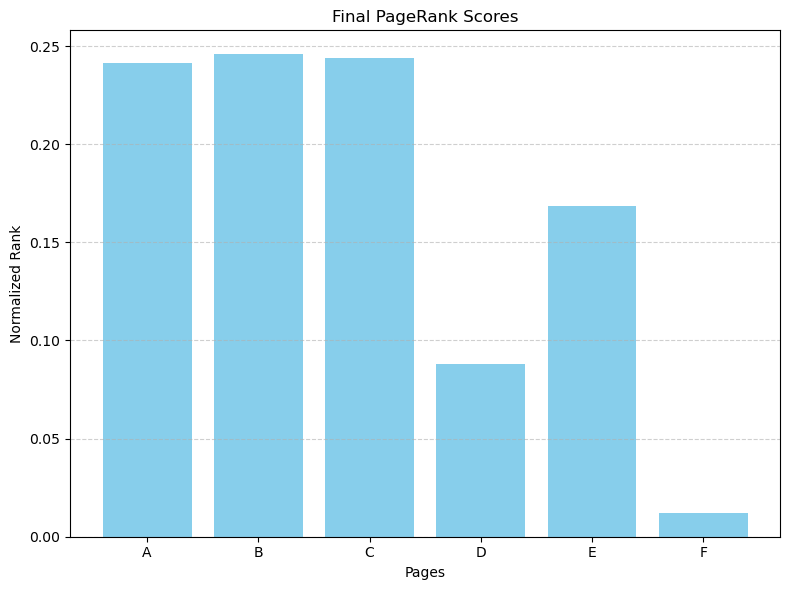

In [1]:
from pyspark.sql import SparkSession
from operator import add
import matplotlib.pyplot as plt

# 1. Initialize Spark session
spark = SparkSession.builder \
    .appName("Custom PageRank") \
    .getOrCreate()

sc = spark.sparkContext

# 2. Modified web graph data
web_graph = [
    ("A", ["B", "C", "D"]),
    ("B", ["C", "E"]),
    ("C", ["A"]),
    ("D", ["C", "E"]),
    ("E", ["B"]),
    ("F", [])  # Disconnected page with no links
]

# 3. Parameters
damping_factor = 0.9  # Adjusted
max_iterations = 20
tolerance = 0.0005    # Adjusted

# 4. Parallelize the web graph
links = sc.parallelize(web_graph)

# 5. Handle empty link lists safely
def safe_links(x):
    return (x[0], x[1]) if x[1] else (x[0], [])

links = links.map(safe_links)

# 6. Initialize ranks
pages = links.map(lambda x: x[0]).distinct()
N = pages.count()
ranks = pages.map(lambda page: (page, 1.0))

# 7. Compute contributions
def compute_contributions(urls_ranks):
    url, (links_list, rank) = urls_ranks
    num_links = len(links_list)
    if num_links == 0:
        return []
    for link in links_list:
        yield (link, rank / num_links)

# 8. Main PageRank loop
for iteration in range(max_iterations):
    contribs = links.join(ranks)
    contribs = contribs.flatMap(compute_contributions)

    new_ranks = contribs.reduceByKey(add) \
        .mapValues(lambda rank: (1 - damping_factor) / N + damping_factor * rank)

    # Fill in any pages that didn't get contributions
    all_pages = pages.map(lambda page: (page, 0.0))
    new_ranks = all_pages.leftOuterJoin(new_ranks) \
        .mapValues(lambda x: x[1] if x[1] is not None else (1 - damping_factor) / N)

    # 9. Check for convergence
    rank_diffs = new_ranks.join(ranks) \
        .map(lambda x: abs(x[1][0] - x[1][1])) \
        .reduce(add)

    ranks = new_ranks
    print(f"Iteration {iteration + 1}: Total difference = {rank_diffs}")
    if rank_diffs < tolerance:
        print("Converged!")
        break

# 10. Normalize ranks so total is 1.0
total_rank = ranks.map(lambda x: x[1]).reduce(add)
ranks = ranks.mapValues(lambda rank: rank / total_rank)

# 11. Collect results
final_ranks = ranks.collect()
final_ranks.sort()  # Sort by page

# 12. Display results
print("\nFinal PageRank Scores:")
for (page, rank) in final_ranks:
    print(f"Page {page}: {rank:.4f}")

# 13. Visualization
pages = [page for page, _ in final_ranks]
scores = [rank for _, rank in final_ranks]

plt.figure(figsize=(8, 6))
plt.bar(pages, scores, color='skyblue')
plt.title("Final PageRank Scores")
plt.xlabel("Pages")
plt.ylabel("Normalized Rank")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Stop Spark
spark.stop()


### What I have done
1. Web graph modified: Customer graph with 6 pages including a disconnected one.
2. Parametres updated: damping_factor = 0.9, tolerance 0.005
3. Error handling: Pages with empty links now handled safely.
4. Rank normalisation: Final ranks are scaled to sum to 1.
5. Visualisation: Ranks plotted with matplotlib.